In [29]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps

# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

theta shape: (181,)
SU shape: (181,)
First few SU values: [274.50568018 273.77890685 271.60879971 268.02578541 263.07987412]


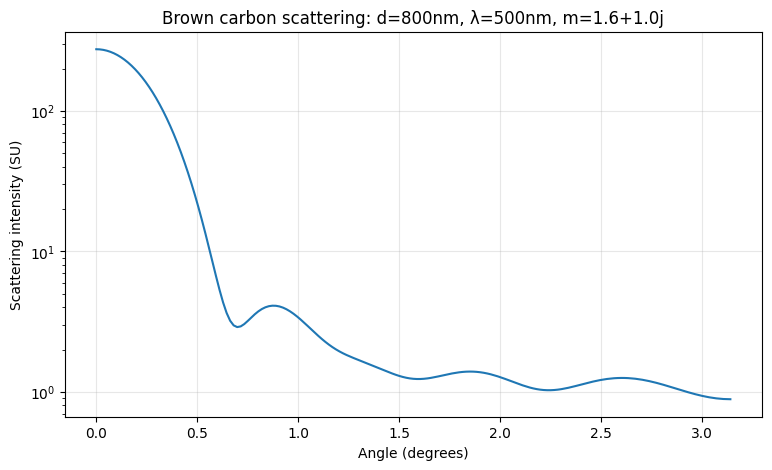

In [30]:
# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm

m = complex(n, k)
theta, SL, SR, SU = ps.ScatteringFunction(
    m, wavelength, diameter,
    minAngle=0, maxAngle=180, angularResolution=1
)

print("theta shape:", theta.shape)
print("SU shape:", SU.shape)
print("First few SU values:", SU[:5])

plt.figure(figsize=(9, 5))
plt.plot(theta, SU)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
N_SAMPLES = 10000


# inputs_saved = np.load('inputs_5d.npy')           # (N, 5)
# outputs_saved = np.load('outputs_5d.npy')         # (N, 1)

# Pre-allocate arrays
inputs = np.zeros((N_SAMPLES, 4))     # everything but angle
outputs = np.zeros((N_SAMPLES, 181))  # 181 angles per curve



# Fixed values for brown carbon
# n = 1.6
# k = 1.0
# m = complex(n, k)

print("Generating training data through physics")

for i in range(N_SAMPLES):
    # Sample random wavelength and diameter
    wavelength = np.random.uniform(450, 550)
    diameter = np.random.uniform(600, 900)
    n = np.random.uniform(1.5, 1.86) # following the paper from Liu et al
    k = np.random.uniform(0.68, 1.00) # following the paper from Liu et al
    m = complex(n, k)
    
    # Run Mie calculation, we'll treat this as the accurate data
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    
    # Store inputs and outputs
    inputs[i] = [wavelength, diameter, n, k]
    outputs[i] = SU
    
    if i % 100 == 0:
        print(f"  {i}/{N_SAMPLES} done")

print("\nDone!")
print("Inputs shape:", inputs.shape)
print("Outputs shape:", outputs.shape)

Generating training data through physics
  0/10000 done
  100/10000 done
  200/10000 done
  300/10000 done
  400/10000 done
  500/10000 done
  600/10000 done
  700/10000 done
  800/10000 done
  900/10000 done
  1000/10000 done
  1100/10000 done
  1200/10000 done
  1300/10000 done
  1400/10000 done
  1500/10000 done
  1600/10000 done
  1700/10000 done
  1800/10000 done
  1900/10000 done
  2000/10000 done
  2100/10000 done
  2200/10000 done
  2300/10000 done
  2400/10000 done
  2500/10000 done
  2600/10000 done
  2700/10000 done
  2800/10000 done
  2900/10000 done
  3000/10000 done
  3100/10000 done
  3200/10000 done
  3300/10000 done
  3400/10000 done
  3500/10000 done
  3600/10000 done
  3700/10000 done
  3800/10000 done
  3900/10000 done
  4000/10000 done
  4100/10000 done
  4200/10000 done
  4300/10000 done
  4400/10000 done
  4500/10000 done
  4600/10000 done
  4700/10000 done
  4800/10000 done
  4900/10000 done
  5000/10000 done
  5100/10000 done
  5200/10000 done
  5300/10000 done

took 4 minutes and 20 seconds for mie theory calculations for 10000 samples

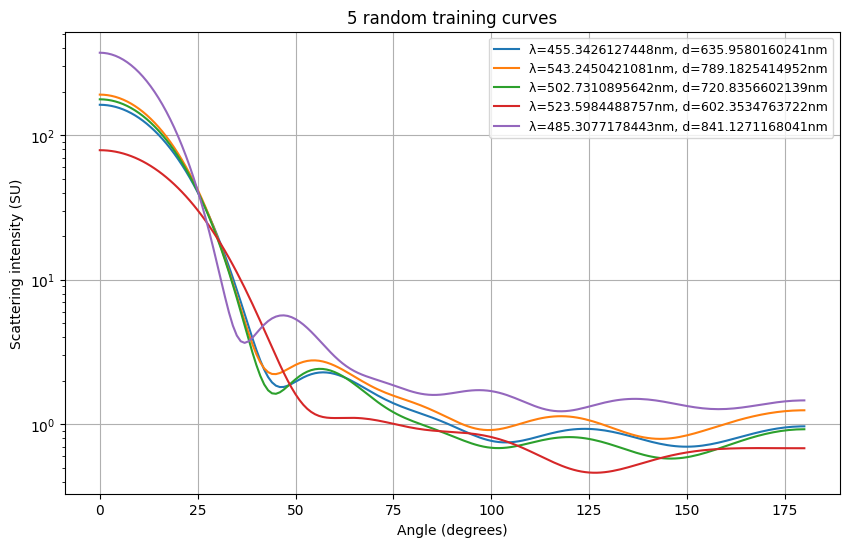

In [32]:
plt.figure(figsize=(10, 6))

# Plot 5 random curves
indices = np.random.choice(N_SAMPLES, 5, replace=False)

# generate lables for each line
for i in indices:
    label = f"λ={inputs[i,0]:.10f}nm, d={inputs[i,1]:.10f}nm"
    plt.plot(outputs[i], label=label)

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("5 random training curves")
plt.yscale('log')
plt.legend(fontsize=9)
plt.grid(True, alpha=1.0)
plt.show()

graphed 5 random training data points, just to see the shape of the results

In [37]:
# 1. Log-transform the outputs
log_outputs = np.log10(outputs)   # base-10 log

# 2. Normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   600-900 → (diameter - 600) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 450) / 100         # wavelength
inputs_norm[:, 1] = (inputs[:, 1] - 600) / 300        # diameter
inputs_norm[:, 2] = (inputs[:, 2] - 1.5) / (1.86-1.5)  # n
inputs_norm[:, 3] = (inputs[:, 3] - 0.68) / (1.00-0.68) # k

# 3. Train/test split — 80% train, 20% test
n_train = int(0.8 * N_SAMPLES)
X_train = inputs_norm[:n_train]
y_train = log_outputs[:n_train]
X_test  = inputs_norm[n_train:]
y_test  = log_outputs[n_train:]

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test  = torch.FloatTensor(X_test)
y_test  = torch.FloatTensor(y_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:",  X_test.shape)
print("y_test shape:",  y_test.shape)
print()
print("Sample input (normalized):", X_train[0])

X_train shape: torch.Size([8000, 4])
y_train shape: torch.Size([8000, 181])
X_test shape: torch.Size([2000, 4])
y_test shape: torch.Size([2000, 181])

Sample input (normalized): tensor([0.3745, 0.9507, 0.7320, 0.5987])


Split the data into training and testing data, formatting the data so it's ready for training. Converting numpy arrays into Tensors.

In [58]:
model = nn.Sequential(
    nn.Linear(4, 128),       # input layer: 4 features to 128 neurons
    nn.GELU(),
    nn.Linear(128, 256),     # hidden layer: 32 -> 64
    nn.GELU(),
    nn.Linear(256, 512),
    nn.GELU(),
    nn.Linear(512, 256),
    nn.GELU(),
    nn.Linear(256, 181)    
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=128, out_features=256, bias=True)
  (3): GELU(approximate='none')
  (4): Linear(in_features=256, out_features=512, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=512, out_features=256, bias=True)
  (7): GELU(approximate='none')
  (8): Linear(in_features=256, out_features=181, bias=True)
)

Total parameters: 343093


building NN layers, applying ReLu between each. Printing the model and counting the number of parameters.

In [59]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [60]:
N_EPOCHS = 200
BATCH_SIZE = 256

train_losses = []
test_losses = []

n_train = X_train.shape[0]   # 800
n_batches = n_train // BATCH_SIZE  # 800 // 32 = 25

print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")

import time

training_start = time.time()

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    
    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0
    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end] # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        
        # Standard 5-step training pattern
        pred = model(X_batch) # predict
        loss = loss_fn(pred, y_batch) # get the loss
        
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    
    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    with torch.no_grad():
        test_pred = model(X_test) #predict on 200 test examples
        test_loss = loss_fn(test_pred, y_test).item() #compute MSE on test set
        test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.2f}s")
print(f"Final loss: {train_losses[-1]:.6e}")
print("\nTraining complete!")


Training: 200 epochs, 31 batches per epoch

Epoch   0  Train Loss: 0.7434598188  Test Loss: 0.6895382404
Epoch  20  Train Loss: 0.0045530712  Test Loss: 0.0043847426
Epoch  40  Train Loss: 0.0030682399  Test Loss: 0.0030409973
Epoch  60  Train Loss: 0.0016325406  Test Loss: 0.0016048911
Epoch  80  Train Loss: 0.0008000238  Test Loss: 0.0007525968
Epoch 100  Train Loss: 0.0002587446  Test Loss: 0.0002491919
Epoch 120  Train Loss: 0.0001740842  Test Loss: 0.0001712164
Epoch 140  Train Loss: 0.0001418388  Test Loss: 0.0001409846
Epoch 160  Train Loss: 0.0001184360  Test Loss: 0.0001181915
Epoch 180  Train Loss: 0.0000970104  Test Loss: 0.0000951506
Total time: 53.47s
Final loss: 7.081620e-05

Training complete!


Training the model. Randomizing the sequence of the training set. Split the set into a training and testing set. Also making sure loss is decreasing over time, ensuring we are approaching a minimum in the cost. Training took 10.7 seconds


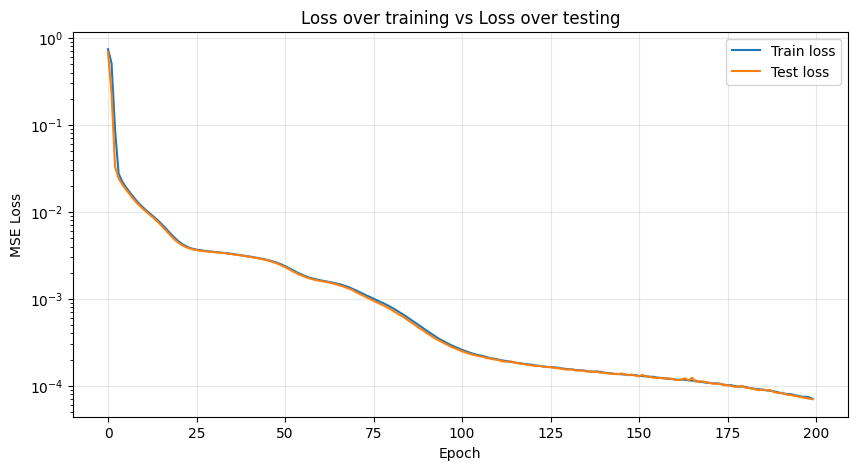

In [61]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

tensor([ 2.0857e+00,  2.0849e+00,  2.0825e+00,  2.0786e+00,  2.0731e+00,
         2.0661e+00,  2.0574e+00,  2.0471e+00,  2.0353e+00,  2.0218e+00,
         2.0067e+00,  1.9899e+00,  1.9715e+00,  1.9513e+00,  1.9295e+00,
         1.9059e+00,  1.8805e+00,  1.8534e+00,  1.8244e+00,  1.7935e+00,
         1.7608e+00,  1.7261e+00,  1.6894e+00,  1.6506e+00,  1.6098e+00,
         1.5668e+00,  1.5217e+00,  1.4743e+00,  1.4246e+00,  1.3725e+00,
         1.3180e+00,  1.2611e+00,  1.2018e+00,  1.1400e+00,  1.0758e+00,
         1.0092e+00,  9.4045e-01,  8.6973e-01,  7.9742e-01,  7.2407e-01,
         6.5042e-01,  5.7749e-01,  5.0657e-01,  4.3925e-01,  3.7729e-01,
         3.2249e-01,  2.7640e-01,  2.4005e-01,  2.1371e-01,  1.9684e-01,
         1.8822e-01,  1.8617e-01,  1.8894e-01,  1.9481e-01,  2.0235e-01,
         2.1041e-01,  2.1811e-01,  2.2483e-01,  2.3016e-01,  2.3386e-01,
         2.3579e-01,  2.3591e-01,  2.3427e-01,  2.3094e-01,  2.2606e-01,
         2.1979e-01,  2.1229e-01,  2.0375e-01,  1.9

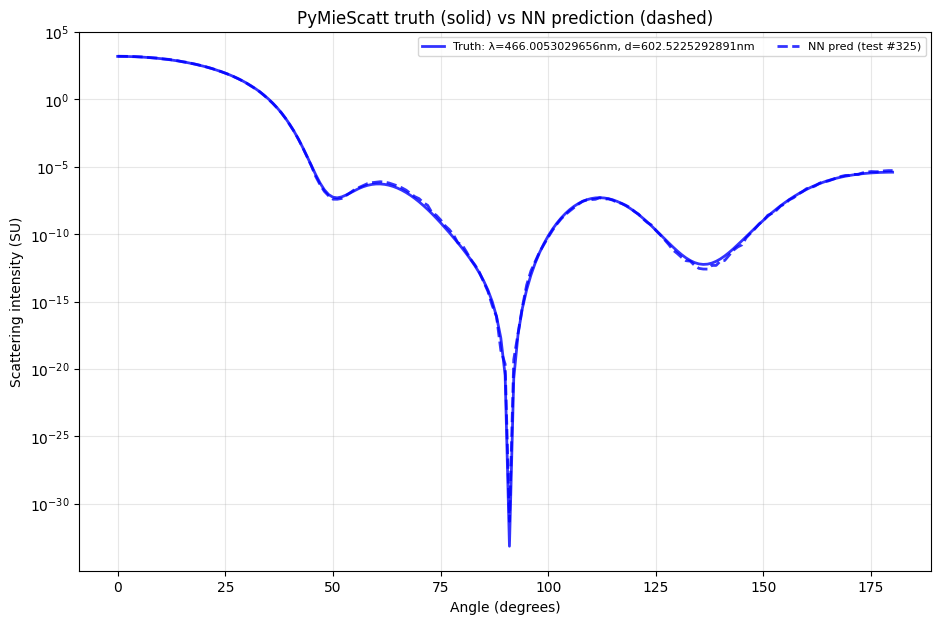

In [62]:
with torch.no_grad():
    test_pred = model(X_test)

# Plot 4 random test cases
plt.figure(figsize=(11, 7))
indices = np.random.choice(len(X_test), 1, replace=False)

print(y_test[indices[0]])
print(test_pred[indices[0]])

# Use different colors for each pair so they're visually distinguishable
colors = ['blue', 'orange', 'green', 'red']

for idx, color in zip(indices, colors):

    # Get the actual physical values (un-normalize)
    norm_w = X_test[idx, 0].item()
    norm_d = X_test[idx, 1].item()
    real_w = norm_w * 100 + 450
    real_d = norm_d * 300 + 600
    
    # Convert log10 back to real brightness values
    true_curve = y_test[idx].numpy() ** 10 # take the log output brightness values and turn them back to their original values
    pred_curve = test_pred[idx].numpy() ** 10 # take the prediction values and turn them back to their original values
    
    # Solid line = truth (PyMieScatt), Dashed line = NN prediction
    plt.plot(true_curve, '-',  color=color, linewidth=2, alpha=0.8,
             label=f"Truth: λ={real_w:.10f}nm, d={real_d:.10f}nm")
    plt.plot(pred_curve, '--', color=color, linewidth=2, alpha=0.8,
             label=f"NN pred (test #{idx})")

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("PyMieScatt truth (solid) vs NN prediction (dashed)")
plt.yscale('log')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

Todo: Still have to try out the tan h compression function between layers. Try to 

Mean squared error (in log space): 2.801425e-05


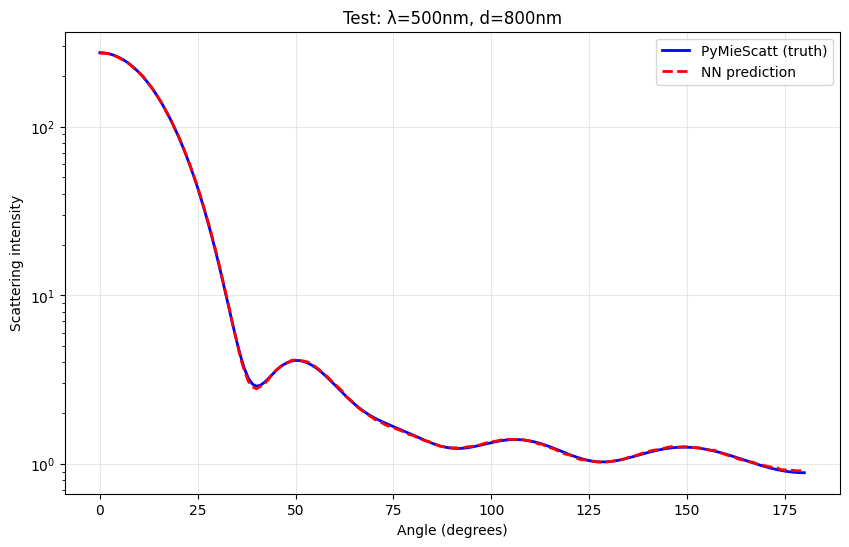

In [63]:
def predict_scattering(wavelength, diameter, n, k):
    """Predict scattering curve for a given wavelength and diameter."""
    # Normalize the inputs the same way we did during training
    norm_wavelength = (wavelength - 450) / 100
    norm_diameter   = (diameter - 600) / 300
    norm_n = (n-1.5)/(1.86-1.5)
    norm_k = (k-0.68)/(0.32)
    
    # Convert to tensor with shape (1, 2) — one example, two features
    input_tensor = torch.FloatTensor([[norm_wavelength, norm_diameter, norm_n, norm_k]])
    
    # Run through the network
    with torch.no_grad():
        log_pred = model(input_tensor)
    
    # Convert from log space back to real brightness
    pred_curve = 10 ** log_pred.numpy().flatten()
    
    return pred_curve


def true_scattering(wavelength, diameter, n, k):
    """Compute the actual PyMieScatt scattering curve."""
    m = complex(n, k) # for any set of parameters
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    return SU


# Pick any wavelength and diameter to test
test_wavelength = 500  # nm
test_diameter = 800   # nm
test_n = 1.6
test_k = 1.0
# Get both predictions
nn_curve = predict_scattering(test_wavelength, test_diameter, test_n, test_k)
true_curve = true_scattering(test_wavelength, test_diameter, test_n, test_k)

# Calculate error
error = np.mean((np.log10(nn_curve) - np.log10(true_curve))**2)
print(f"Mean squared error (in log space): {error:.6e}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(true_curve, '-',  color='blue', linewidth=2, label='PyMieScatt (truth)')
plt.plot(nn_curve,   '--', color='red',  linewidth=2, label='NN prediction')
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity")
plt.title(f"Test: λ={test_wavelength}nm, d={test_diameter}nm")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

still understanding this part... work in progress. Doesn't look too accurate though. The neural network is able to predict values within it's trained range very well. As soon as it is given a value that is not within the trained range, it starts to perform more poorly. Values within the training range are predicted very accurately. If the neural network is asked to predict with wavelength and diameter outside of the training range, it is more inaccurate.

This section is used to generate some 2d plots. We'll begin by generating the logspaced diameter testing data.

In [64]:
N_D_SPANNING_DATA = 900
m = complex(1.6, 1.0) # match the m value the NN was trained on
fixed_lambda = 500 # I will be varying diameter not wavelength

# Log-spaced diameter sweep — wider than training range
d_span = np.logspace(np.log10(300), np.log10(1200), N_D_SPANNING_DATA)

print("Computing Brightness for Each Diamaeter with PyMieScatt")
truth = np.zeros((N_D_SPANNING_DATA, 181)) # create one dimensional array of 0s

# generate the pyMieScatt curve for each diameter value
for i, d in enumerate(d_span):
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, fixed_lambda, d, minAngle=0, maxAngle=180, angularResolution=1
    )

    # add it in it's spot in the array
    truth[i] = SU
    if i % 50 == 0:
        print(f"  {i}/{N_D_SPANNING_DATA}")

# === Predictions from NN ===
print("Computing NN sweep...")
nn_pred = np.zeros((N_D_SPANNING_DATA, 181))

for i, d in enumerate(d_span):
    norm_w = (fixed_lambda - 450) / 100
    norm_d = (d - 600) / 300
    inp = torch.FloatTensor([[norm_w, norm_d, 1.6, 1.0]])
    with torch.no_grad():
        log_pred = model(inp)
    nn_pred[i] = 10 ** log_pred.numpy().flatten()

print(f"\nDone!")
print(f"Diameter range: {d_span[0]:.0f} to {d_span[-1]:.0f} nm")
print(f"Training was: 600 to 900 nm")


Computing Brightness for Each Diamaeter with PyMieScatt
  0/900
  50/900
  100/900
  150/900
  200/900
  250/900
  300/900
  350/900
  400/900
  450/900
  500/900
  550/900
  600/900
  650/900
  700/900
  750/900
  800/900
  850/900
Computing NN sweep...

Done!
Diameter range: 300 to 1200 nm
Training was: 600 to 900 nm


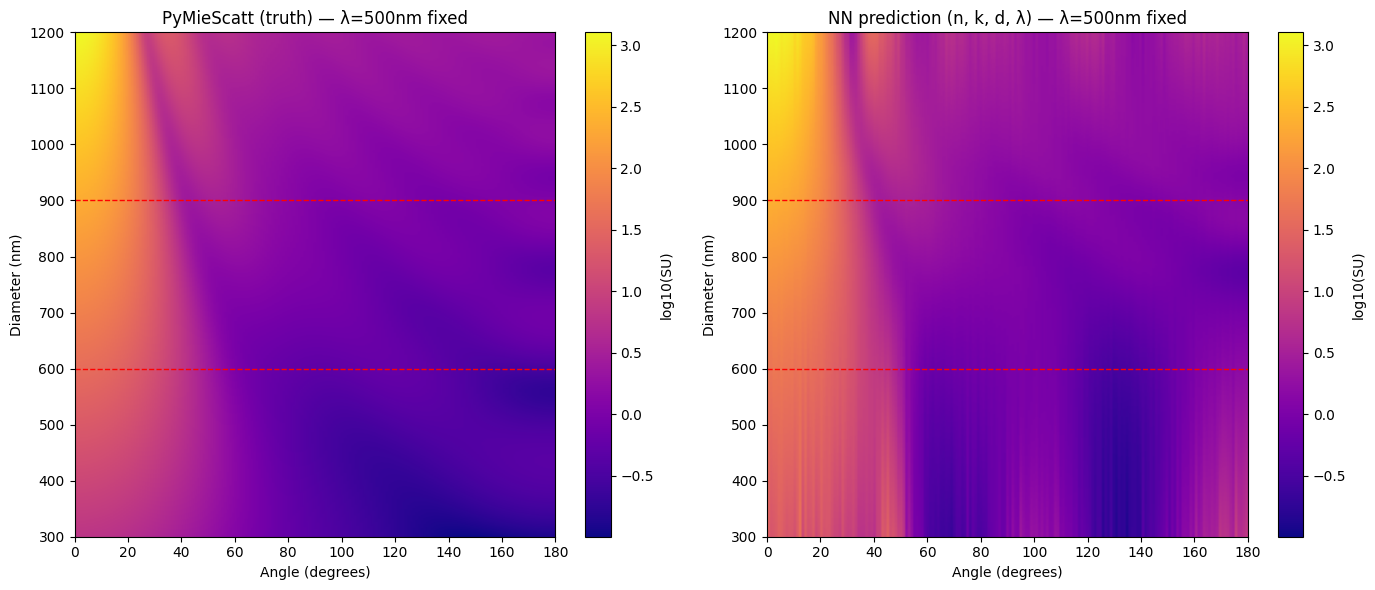

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use the same color scale across both plots so they're directly comparable
vmin = np.log10(truth).min()
vmax = np.log10(truth).max()

# === PyMieScatt truth ===
im1 = axes[0].imshow(
    np.log10(truth),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[0].set_title(f"PyMieScatt (truth) — λ={fixed_lambda}nm fixed")
axes[0].set_xlabel("Angle (degrees)")
axes[0].set_ylabel("Diameter (nm)")
# Show training range boundaries
plt.colorbar(im1, ax=axes[0], label='log10(SU)')

# === NN prediction ===
im2 = axes[1].imshow(
    np.log10(nn_pred),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)

for ax in axes:
    ax.axhline(y=600, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=900, color='red', linestyle='--', linewidth=1)
    
axes[1].set_title(f"NN prediction (n, k, d, λ) — λ={fixed_lambda}nm fixed")
axes[1].set_xlabel("Angle (degrees)")
axes[1].set_ylabel("Diameter (nm)")
plt.colorbar(im2, ax=axes[1], label='log10(SU)')

plt.tight_layout()
plt.show()

Running benchmark with 10 repetitions per method...

Run 1/10: NN=1.17ms  PyMieScatt=41.44ms
Run 2/10: NN=0.54ms  PyMieScatt=39.28ms
Run 3/10: NN=0.82ms  PyMieScatt=39.82ms
Run 4/10: NN=0.41ms  PyMieScatt=30.42ms
Run 5/10: NN=1.27ms  PyMieScatt=40.47ms
Run 6/10: NN=0.81ms  PyMieScatt=37.92ms
Run 7/10: NN=0.57ms  PyMieScatt=38.12ms
Run 8/10: NN=0.47ms  PyMieScatt=27.26ms
Run 9/10: NN=1.35ms  PyMieScatt=39.80ms
Run 10/10: NN=0.89ms  PyMieScatt=38.11ms

--- Average times ---
NN:         0.83 ms (±0.32 ms)
PyMieScatt: 37.26 ms (±4.40 ms)
pyMieDiff:  21.55 ms (±6.07 ms)


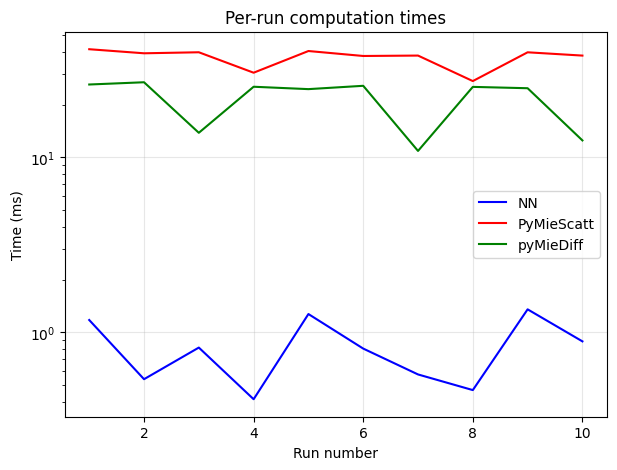

In [66]:
import time
import pymiediff as pmd
# Test parameters
n = 1.7
k = 0.85
wavelength = 500
diameter = 800

# Number of times to repeat each test (for averaging)
N_RUNS = 10

# Lists to store times
nn_times = []
pymiescatt_times = []
pymiediff_times = []

print(f"Running benchmark with {N_RUNS} repetitions per method...\n")

for run in range(N_RUNS):
    # --- Time NN prediction ---
    start = time.time()
    _ = predict_scattering(wavelength, diameter, n, k)
    nn_times.append(time.time() - start)
    
    # --- Time PyMieScatt ---
    start = time.time()
    m = complex(n, k)
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    pymiescatt_times.append(time.time() - start)
    
    # --- Time pyMieDiff ---
    start = time.time()
    wl0 = torch.tensor([float(wavelength)])
    k0 = 2 * torch.pi / wl0
    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env=1.00
    )

    theta_t = torch.arange(0, 181) * torch.pi/181
    angle_scattering = p.get_angular_scattering(k0=k0, theta=theta_t)
    pymiediff_times.append(time.time() - start)
    
    print(f"Run {run+1}/{N_RUNS}: NN={nn_times[-1]*1000:.2f}ms  PyMieScatt={pymiescatt_times[-1]*1000:.2f}ms")

# Summary stats
print(f"\n--- Average times ---")
print(f"NN:         {np.mean(nn_times)*1000:.2f} ms (±{np.std(nn_times)*1000:.2f} ms)")
print(f"PyMieScatt: {np.mean(pymiescatt_times)*1000:.2f} ms (±{np.std(pymiescatt_times)*1000:.2f} ms)")
print(f"pyMieDiff:  {np.mean(pymiediff_times)*1000:.2f} ms (±{np.std(pymiediff_times)*1000:.2f} ms)")

# Plot
fig, axes = plt.subplots(figsize=(7, 5))

# Left: time series of each run
axes.plot(range(1, N_RUNS+1), [t*1000 for t in nn_times], label='NN', color='blue')
axes.plot(range(1, N_RUNS+1), [t*1000 for t in pymiescatt_times], label='PyMieScatt', color='red')
axes.plot(range(1, N_RUNS+1), [t*1000 for t in pymiediff_times], label='pyMieDiff', color='green')
axes.set_xlabel('Run number')
axes.set_ylabel('Time (ms)')
axes.set_title('Per-run computation times')
axes.set_yscale('log')
axes.legend()
axes.grid(True, alpha=0.3)

plt.show()

In [67]:
test_mse = ((model(X_test) - y_test) ** 2).mean().item()
print(f"Final MSE on test set: {test_mse:.8f}")

Final MSE on test set: 0.00007006
